# ACME v4.0

Running all FM216 experiments with ACME-Lite...

=== Quadratic cond=10 ===
 Trial 1/3
  ACME-Lite: 2500 iterations (or max=2500)
  Adam: 1037 iterations (or max=2500)
  SGDM: 156 iterations (or max=2500)
  RMSprop: 2500 iterations (or max=2500)
 Trial 2/3
  ACME-Lite: 1529 iterations (or max=2500)
  Adam: 731 iterations (or max=2500)
  SGDM: 159 iterations (or max=2500)
  RMSprop: 559 iterations (or max=2500)
 Trial 3/3
  ACME-Lite: 1832 iterations (or max=2500)
  Adam: 1164 iterations (or max=2500)
  SGDM: 163 iterations (or max=2500)
  RMSprop: 2500 iterations (or max=2500)


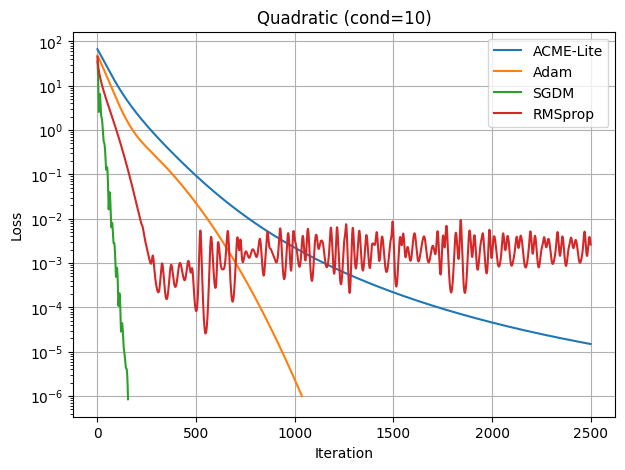


=== Quadratic cond=100 ===
 Trial 1/3
  ACME-Lite: 2500 iterations (or max=2500)
  Adam: 2500 iterations (or max=2500)
  SGDM: 178 iterations (or max=2500)
  RMSprop: 2500 iterations (or max=2500)
 Trial 2/3
  ACME-Lite: 2500 iterations (or max=2500)
  Adam: 1359 iterations (or max=2500)
  SGDM: 182 iterations (or max=2500)
  RMSprop: 2500 iterations (or max=2500)
 Trial 3/3
  ACME-Lite: 2500 iterations (or max=2500)
  Adam: 2500 iterations (or max=2500)
  SGDM: 185 iterations (or max=2500)
  RMSprop: 2500 iterations (or max=2500)


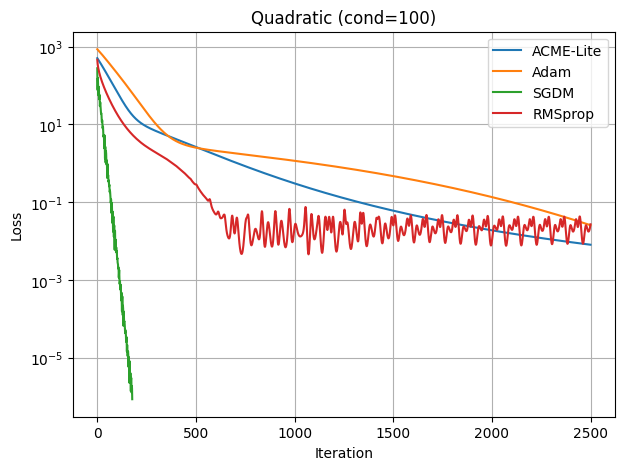


=== Rosenbrock Function ===
 Trial 1/3
  ACME-Lite: 5000 iterations (or max=5000)
  Adam: 5000 iterations (or max=5000)
  SGDM: 837 iterations (or max=5000)
  RMSprop: 5000 iterations (or max=5000)
 Trial 2/3
  ACME-Lite: 5000 iterations (or max=5000)
  Adam: 5000 iterations (or max=5000)
  SGDM: 837 iterations (or max=5000)
  RMSprop: 5000 iterations (or max=5000)
 Trial 3/3
  ACME-Lite: 5000 iterations (or max=5000)
  Adam: 5000 iterations (or max=5000)
  SGDM: 837 iterations (or max=5000)
  RMSprop: 5000 iterations (or max=5000)


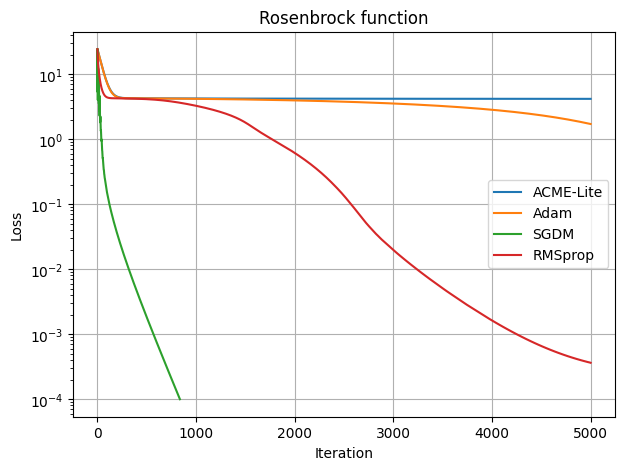


=== MNIST MLP (784-128-64-10) ===

Optimizer: ACME-Lite
  Epoch 01/20 | train loss=0.4438, test acc=0.9328, time=3.46s
  Epoch 02/20 | train loss=0.1919, test acc=0.9546, time=3.40s
  Epoch 03/20 | train loss=0.1401, test acc=0.9615, time=3.36s
  Epoch 04/20 | train loss=0.1093, test acc=0.9653, time=3.32s
  Epoch 05/20 | train loss=0.0882, test acc=0.9700, time=3.27s
  Epoch 06/20 | train loss=0.0735, test acc=0.9726, time=3.27s
  Epoch 07/20 | train loss=0.0624, test acc=0.9746, time=3.25s
  Epoch 08/20 | train loss=0.0529, test acc=0.9745, time=3.62s
  Epoch 09/20 | train loss=0.0458, test acc=0.9761, time=3.55s
  Epoch 10/20 | train loss=0.0390, test acc=0.9784, time=3.70s
  Epoch 11/20 | train loss=0.0345, test acc=0.9766, time=3.27s
  Epoch 12/20 | train loss=0.0289, test acc=0.9778, time=3.37s
  Epoch 13/20 | train loss=0.0245, test acc=0.9769, time=3.48s
  Epoch 14/20 | train loss=0.0212, test acc=0.9776, time=3.45s
  Epoch 15/20 | train loss=0.0188, test acc=0.9768, time=3.35

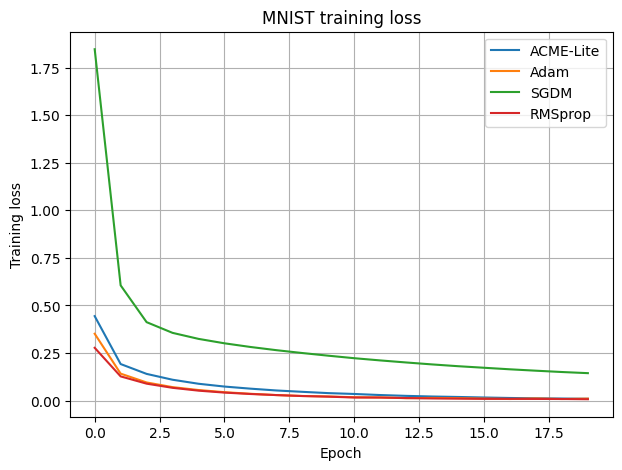

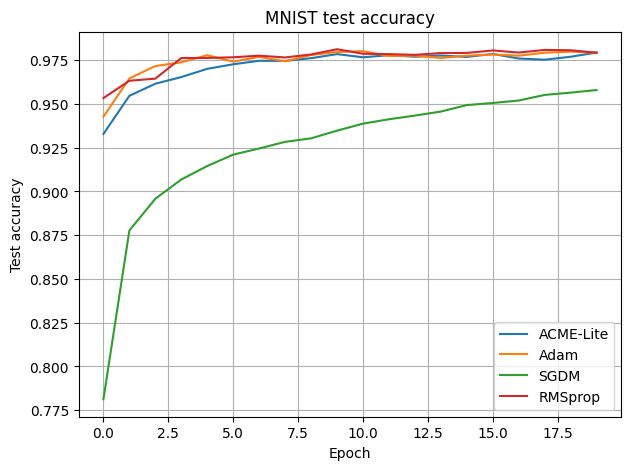


All experiments completed.


In [1]:
# ================================================================
# FM216 PROJECT – FINAL EXPERIMENT SUITE WITH ACME-LITE
# Custom optimizer: ACME-Lite (Adam + kurtosis scaling)
# Baselines: Adam, SGD+Momentum, RMSprop
# Benchmarks:
#   1. Quadratic cond=10
#   2. Quadratic cond=100
#   3. Rosenbrock
#   4. MNIST MLP (20 epochs)
# ================================================================

import math
import time
import random
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (7, 5)

# ================================================================
# Device + Seed
# ================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_SEED = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(BASE_SEED)


# ================================================================
# ACME-Lite Optimizer (Adam + Kurtosis Scaling)
# ================================================================
class ACME_Lite(torch.optim.Optimizer):
    """
    ACME-Lite: Adam backbone + kurtosis-based step-size modulation.

    Moments (Adam):
        m_t, v_t  – standard Adam first & second moments

    Novelty:
        E4_t      – EMA of g_t^4
        K_t       – kurtosis-like ratio E4_t / (v_hat_t^2 + eps)
        s_t       – scaling factor 1 / (1 + lambda_k * K_t)

    Final update (per-parameter, elementwise):
        theta_{t+1} = theta_t - eta * s_t * m_hat_t / (sqrt(v_hat_t) + eps)
    """

    def __init__(
        self,
        params,
        lr=1e-3,
        betas=(0.9, 0.999),
        beta4=None,          # if None, use beta2
        lambda_k=0.1,        # strength of kurtosis scaling
        eps=1e-8,
    ):
        if lr <= 0.0:
            raise ValueError(f"Invalid learning rate: {lr}")
        if not 0.0 < betas[0] < 1.0:
            raise ValueError(f"Invalid beta1: {betas[0]}")
        if not 0.0 < betas[1] < 1.0:
            raise ValueError(f"Invalid beta2: {betas[1]}")
        if beta4 is None:
            beta4 = betas[1]
        if not 0.0 < beta4 < 1.0:
            raise ValueError(f"Invalid beta4: {beta4}")
        defaults = dict(
            lr=lr,
            betas=betas,
            beta4=beta4,
            lambda_k=lambda_k,
            eps=eps,
        )
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            lr = group["lr"]
            beta1, beta2 = group["betas"]
            beta4 = group["beta4"]
            lambda_k = group["lambda_k"]
            eps = group["eps"]

            for p in group["params"]:
                if p.grad is None:
                    continue
                grad = p.grad

                state = self.state[p]
                if len(state) == 0:
                    # state initialization
                    state["step"] = 0
                    state["m"] = torch.zeros_like(p.data)
                    state["v"] = torch.zeros_like(p.data)
                    state["E4"] = torch.zeros_like(p.data)

                m = state["m"]
                v = state["v"]
                E4 = state["E4"]

                state["step"] += 1
                t = state["step"]

                # --- Standard Adam moments ---
                m.mul_(beta1).add_(grad, alpha=1 - beta1)
                v.mul_(beta2).addcmul_(grad, grad, value=1 - beta2)

                # --- New: 4th moment for kurtosis ---
                g4 = grad * grad
                g4 = g4 * g4        # g^4
                E4.mul_(beta4).add_(g4, alpha=1 - beta4)

                # Bias corrections
                m_hat = m / (1 - beta1**t)
                v_hat = v / (1 - beta2**t)

                # Kurtosis-like ratio K_t = E4 / (v_hat^2 + eps)
                K_t = E4 / (v_hat * v_hat + eps)

                # Scaling factor s_t = 1 / (1 + lambda_k * K_t)
                s_t = 1.0 / (1.0 + lambda_k * K_t)

                # Final ACME-Lite update (elementwise)
                denom = torch.sqrt(v_hat) + eps
                step = lr * s_t * (m_hat / denom)

                p.data.add_(-step)

        return loss


# ================================================================
# Quadratic Helpers
# ================================================================
def make_spd_matrix(dim=20, cond=10):
    """Generate a symmetric positive definite matrix with given condition number."""
    V, _ = np.linalg.qr(np.random.randn(dim, dim))
    eigs = np.linspace(1, cond, dim)
    return V @ np.diag(eigs) @ V.T


# ================================================================
# Quadratic Runner
# ================================================================
def run_quadratic(cond, dim=20, trials=3, max_iter=2500, tol=1e-6):
    print(f"\n=== Quadratic cond={cond} ===")

    def f_quad(x, Q):
        return 0.5 * (x @ Q @ x)

    # Same base lr for all optimizers; ACME-Lite uses lambda_k as extra hyperparam
    OPTS = {
        "ACME-Lite": lambda params: ACME_Lite(params, lr=1e-2, lambda_k=0.2),
        "Adam":      lambda params: torch.optim.Adam(params, lr=1e-2),
        "SGDM":      lambda params: torch.optim.SGD(params, lr=1e-2, momentum=0.9),
        "RMSprop":   lambda params: torch.optim.RMSprop(params, lr=1e-2),
    }

    logs = {name: [] for name in OPTS}

    for trial in range(trials):
        print(f" Trial {trial+1}/{trials}")
        Q_np = make_spd_matrix(dim, cond)
        Q = torch.tensor(Q_np, dtype=torch.float32, device=device)

        for name, opt_ctor in OPTS.items():
            x = torch.randn(dim, device=device, requires_grad=True)
            opt = opt_ctor([x])

            losses = []
            for it in range(max_iter):
                opt.zero_grad()
                loss = f_quad(x, Q)
                losses.append(loss.item())
                if loss.item() < tol:
                    break
                loss.backward()
                opt.step()

            logs[name].append(losses)
            print(f"  {name}: {len(losses)} iterations (or max={max_iter})")

    # Plot first trial
    for name in OPTS:
        plt.plot(logs[name][0], label=name)
    plt.yscale("log")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title(f"Quadratic (cond={cond})")
    plt.grid(True)
    plt.legend()
    plt.show()

    return logs


# ================================================================
# Rosenbrock Runner
# ================================================================
def run_rosenbrock(max_iter=5000, tol=1e-4, trials=3):
    print("\n=== Rosenbrock Function ===")

    def f_rosen(theta):
        x, y = theta[0], theta[1]
        return (1 - x)**2 + 100 * (y - x**2)**2

    OPTS = {
        "ACME-Lite": lambda params: ACME_Lite(params, lr=1e-3, lambda_k=0.3),
        "Adam":      lambda params: torch.optim.Adam(params, lr=1e-3),
        "SGDM":      lambda params: torch.optim.SGD(params, lr=1e-3, momentum=0.9),
        "RMSprop":   lambda params: torch.optim.RMSprop(params, lr=1e-3),
    }

    logs = {name: [] for name in OPTS}

    for trial in range(trials):
        print(f" Trial {trial+1}/{trials}")

        for name, opt_ctor in OPTS.items():
            theta = torch.tensor([-1.2, 1.0], device=device, requires_grad=True)
            opt = opt_ctor([theta])

            losses = []
            for it in range(max_iter):
                opt.zero_grad()
                loss = f_rosen(theta)
                losses.append(loss.item())
                if loss.item() < tol:
                    break
                loss.backward()
                opt.step()

            logs[name].append(losses)
            print(f"  {name}: {len(losses)} iterations (or max={max_iter})")

    # Plot first trial
    for name in OPTS:
        plt.plot(logs[name][0], label=name)
    plt.yscale("log")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title("Rosenbrock function")
    plt.grid(True)
    plt.legend()
    plt.show()

    return logs


# ================================================================
# MNIST Runner (MLP 784-128-64-10)
# ================================================================
class MNISTNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

def mnist_loaders(batch_size=64):
    transform = transforms.ToTensor()
    train_ds = datasets.MNIST("./data", train=True, download=True, transform=transform)
    test_ds  = datasets.MNIST("./data", train=False, download=True, transform=transform)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader

def train_one_epoch(model, opt, loader):
    model.train()
    total_loss = 0.0
    total_samples = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        logits = model(x)
        loss = F.cross_entropy(logits, y)
        loss.backward()
        opt.step()
        total_loss += loss.item() * x.size(0)
        total_samples += x.size(0)
    return total_loss / total_samples

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)
    return correct / total

def run_mnist(epochs=20, base_lr=1e-3):
    print("\n=== MNIST MLP (784-128-64-10) ===")

    train_loader, test_loader = mnist_loaders()

    OPTS = {
        "ACME-Lite": lambda params: ACME_Lite(params, lr=5e-4, lambda_k=0.2),
        "Adam":      lambda params: torch.optim.Adam(params, lr=base_lr),
        "SGDM":      lambda params: torch.optim.SGD(params, lr=base_lr, momentum=0.9),
        "RMSprop":   lambda params: torch.optim.RMSprop(params, lr=base_lr),
    }

    results = {}

    for name, opt_ctor in OPTS.items():
        print(f"\nOptimizer: {name}")
        set_seed(BASE_SEED + 123)  # same init for fair comparison
        model = MNISTNet().to(device)
        opt = opt_ctor(model.parameters())

        train_losses = []
        test_accs = []

        for epoch in range(1, epochs + 1):
            t0 = time.time()
            train_loss = train_one_epoch(model, opt, train_loader)
            acc = evaluate(model, test_loader)
            dt = time.time() - t0

            train_losses.append(train_loss)
            test_accs.append(acc)
            print(
                f"  Epoch {epoch:02d}/{epochs} | "
                f"train loss={train_loss:.4f}, "
                f"test acc={acc:.4f}, "
                f"time={dt:.2f}s"
            )

        results[name] = {
            "train_losses": np.array(train_losses),
            "test_accs": np.array(test_accs),
        }

    # Plot training loss
    plt.figure()
    for name in results:
        plt.plot(results[name]["train_losses"], label=name)
    plt.xlabel("Epoch")
    plt.ylabel("Training loss")
    plt.title("MNIST training loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    # Plot test accuracy
    plt.figure()
    for name in results:
        plt.plot(results[name]["test_accs"], label=name)
    plt.xlabel("Epoch")
    plt.ylabel("Test accuracy")
    plt.title("MNIST test accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()

    return results


# ================================================================
# MAIN: RUN ALL EXPERIMENTS
# ================================================================
print("Running all FM216 experiments with ACME-Lite...")

quad10_logs  = run_quadratic(cond=10)
quad100_logs = run_quadratic(cond=100)
ros_logs     = run_rosenbrock()
mnist_results = run_mnist()

print("\nAll experiments completed.")